### PyTorch HPC scaffold

This notebook contains implementation for training a small CNN on CIFAR-10, with production grade wiring around.

Training loop with mixed precision, cosine LR scheduling, gradient clipping, and checkpoint saving


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.amp import GradScaler, autocast
import time, os

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Dataset preprocessing. `Compose` chains transforms into a pipeline. So series of following tranformations are applied:
- `RandomHorizontalFlip`: with 50% probability, image is flipped (for data augmentation)
- `RandomCrop(32, padding=4`) - pads 32x32 image to 40x40 with zeros, then randomly crops back to 32x32 (for model to learn that objects aren't always centered)
- `ToTensor()` - converts PIL image (HxWxC, vals 0-255) to a PyTorch tensor (CxHxW, vals 0.0-1.0). Transposes the channel dimension bcs PT expects channels first
- `Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))` - for each of the 3 color channels, subtracts 0.5 and divides by 0.5. This remaps [0,1] -> [-1,1] (NNs train better when data is centered around 0)

`train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)`
- `num_workers=2` spawns two background processes to load and preprocess data in parallel while the GPU is training
- `pin_memory=True` allocates data in page-locked CPU memory, which allows for faster CPU -> GPU transfer




In [7]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_set   = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

Model architecure

In [8]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallCNN().to(device)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast(device_type=device.type, enabled=(device.type in ['cuda', 'mps'])):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        # Scaled backward + gradient clipping
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        correct += outputs.argmax(1).eq(targets).sum().item()
        total += targets.size(0)

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            correct += outputs.argmax(1).eq(targets).sum().item()
            total += targets.size(0)
    return total_loss / len(loader), 100. * correct / total

model.state_dict() returns all the learned weights as a dictionary. torch.save serializes it to disk. Saving only the best checkpoint (by val accuracy) means if training degrades later, you haven't lost your best model. In production you'd also save the optimizer state so you can resume training exactly.

In [12]:
NUM_EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = GradScaler(device.type, enabled=(device.type in ['cuda', 'mps'])) # GradScaler only for CUDA

os.makedirs("checkpoints", exist_ok=True)
best_val_acc = 0.0
history = []

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, epoch)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    scheduler.step()

    elapsed = time.time() - t0
    history.append({
    "epoch":      epoch + 1,
    "train_loss": train_loss,
    "train_acc":  train_acc,
    "val_loss":   val_loss,
    "val_acc":    val_acc
    })
    print(f"Epoch {epoch+1:02d} | train_loss {train_loss:.3f} | train_acc {train_acc:.1f}% | val_acc {val_acc:.1f}% | lr {scheduler.get_last_lr()[0]:.2e} | {elapsed:.1f}s")

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"epoch": epoch+1, "model_state": model.state_dict(), "val_acc": val_acc}, "checkpoints/best.pt")
        print(f"  ✓ New best saved ({val_acc:.1f}%)")

print(f"\nDone. Best val accuracy: {best_val_acc:.1f}%")

Epoch 01 | train_loss 0.930 | train_acc 67.3% | val_acc 71.7% | lr 9.76e-04 | 23.2s
  ✓ New best saved (71.7%)
Epoch 02 | train_loss 0.895 | train_acc 68.7% | val_acc 71.8% | lr 9.05e-04 | 22.8s
  ✓ New best saved (71.8%)
Epoch 03 | train_loss 0.856 | train_acc 70.0% | val_acc 72.3% | lr 7.94e-04 | 22.7s
  ✓ New best saved (72.3%)
Epoch 04 | train_loss 0.821 | train_acc 71.4% | val_acc 74.6% | lr 6.55e-04 | 22.7s
  ✓ New best saved (74.6%)
Epoch 05 | train_loss 0.783 | train_acc 72.7% | val_acc 73.9% | lr 5.00e-04 | 23.2s
Epoch 06 | train_loss 0.749 | train_acc 73.8% | val_acc 76.3% | lr 3.45e-04 | 22.0s
  ✓ New best saved (76.3%)
Epoch 07 | train_loss 0.712 | train_acc 75.2% | val_acc 76.8% | lr 2.06e-04 | 22.9s
  ✓ New best saved (76.8%)
Epoch 08 | train_loss 0.684 | train_acc 76.2% | val_acc 78.3% | lr 9.55e-05 | 22.4s
  ✓ New best saved (78.3%)
Epoch 09 | train_loss 0.658 | train_acc 77.0% | val_acc 79.2% | lr 2.45e-05 | 22.8s
  ✓ New best saved (79.2%)
Epoch 10 | train_loss 0.649 

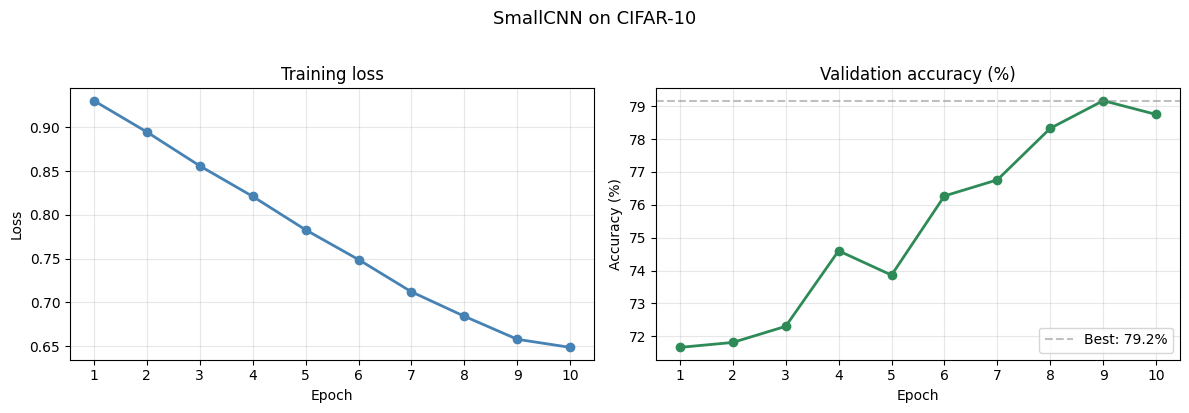

Saved to training_curves.png


In [13]:
import matplotlib.pyplot as plt

epochs     = [h["epoch"]      for h in history]
train_loss = [h["train_loss"] for h in history]
val_acc    = [h["val_acc"]    for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(epochs, train_loss, marker='o', linewidth=2, color='steelblue')
ax1.set_title("Training loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(epochs)
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs, val_acc, marker='o', linewidth=2, color='seagreen')
ax2.set_title("Validation accuracy (%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_xticks(epochs)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=max(val_acc), color='gray', linestyle='--', alpha=0.5, label=f"Best: {max(val_acc):.1f}%")
ax2.legend()

plt.suptitle("SmallCNN on CIFAR-10", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to training_curves.png")